In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df=pd.read_csv('height-weight.csv')

In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


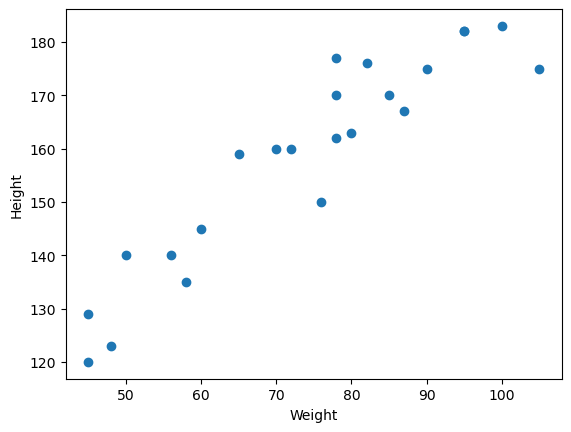

In [5]:
### Scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [6]:
## correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


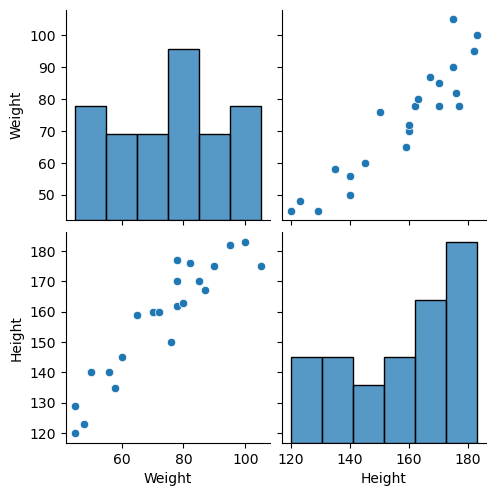

In [7]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [8]:
## Independent and dependent features

X = df.drop('Height', axis=1) ## Independent features. This should be a dataframe or 2 dimensional array

In [9]:
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [10]:
y = df['Height'] ## The dependent feature needs to be a series or 1 dimension
y.head()

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [11]:
X.shape

(23, 1)

In [12]:
np.array(X).shape ## same as above

(23, 1)

In [13]:
y.shape

(23,)

In [14]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [15]:
X_train.shape

(17, 1)

In [16]:
y_train.shape

(17,)

In [17]:
## Standardization
from sklearn.preprocessing import StandardScaler


In [18]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)

In [19]:
X_test=scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [20]:
## Appliy Simple Linear regression
from sklearn.linear_model import LinearRegression

In [21]:
regression=LinearRegression(n_jobs=-1)

In [22]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [23]:
## Lets get the returned values
print('Coefficient or Slope:', regression.coef_) 
print('Intercept:', regression.intercept_)

Coefficient or Slope: [17.2982057]
Intercept: 156.47058823529412


In [24]:
## Let us get the predicted values Using X_train
y_train_predict = regression.predict(X_train)
y_train_predict ## We will use this to view the model line (Best fit line)

array([141.30649667, 185.31934779, 162.26499721, 130.82724641,
       180.07972266, 127.68347133, 143.40234673, 153.88159699,
       160.16914715, 132.92309646, 139.21064662, 155.97744705,
       174.84009753, 166.45669731, 169.60047239, 171.69632245,
       164.36084726])

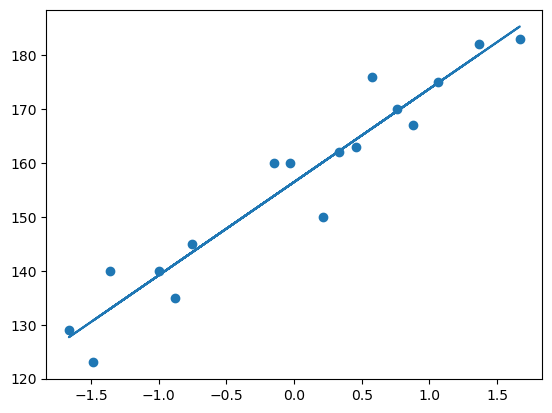

In [25]:
## Lets plot training data with the best-fit data
plt.scatter(X_train,y_train)
plt.plot(X_train, y_train_predict) ## THe best fit line

In [26]:
### Prediction Test data
# 1. predicted height outputs = intercept + coef_(Weights)
# 2. y_pred_test = 156.470 + 70.29(X_test)

In [27]:
## Predicton of test data
y_pred = regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [28]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared error:', mse)
print('Mean Absolute error:', mae)
print('Root Mean Sqaured error:', rmse)




Mean Squared error: 114.84069295228699
Mean Absolute error: 9.665125886795005
Root Mean Sqaured error: 10.716374991212605


In [29]:
## using r squared
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print('r square:', score)


r square: 0.7360826717981276


It is not very good accuracy but we will go into more advanced methods to improve this model

In [30]:
## Using Adjusted r squared

adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted r square:', adjusted_score)

Adjusted r square: 0.6701033397476595


In [31]:
## OLS Linear Regression (Ordinary Least Square)
import statsmodels.api as sm

In [32]:
model=sm.OLS(y_train, X_train).fit()

In [33]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [34]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 10 May 2026   Prob (F-statistic):                       0.664
Time:                        08:48:11   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


In [35]:
## Prediction for new data
## Lets say we want to predict the height of a person of weight 72

regression.predict([[72]]) ## remember to input with double bracket(dataframe)

array([1401.94139895])

In [36]:
## You can see that the height is not looking accurate
## This is because we standardized the training data
## Therefore we have to standardize any input

regression.predict(scaler.transform([[72]]))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

In [37]:
## This is a more correct output

### Multiple Linear Regression

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [39]:
df_index = pd.read_csv('economic_index.csv')

In [40]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [41]:
## drop unnecessary column eg year and month

df_index=df_index.drop(columns=['Unnamed: 0','year','month'],axis=1)
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [42]:
## check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

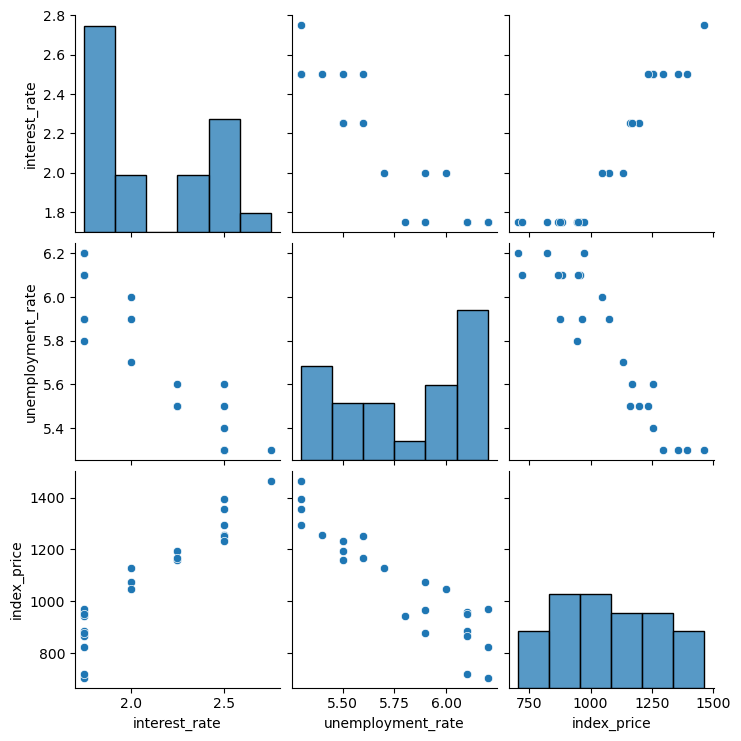

In [43]:
import seaborn as sns
sns.pairplot(data=df_index)

In [44]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

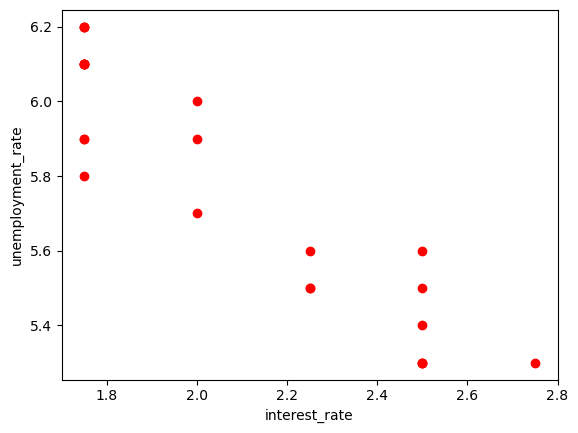

In [45]:
## Visualize the data points more closely

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'],c='r')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')

In [46]:
## Dependent and independent features (we just decided to use iloc)

X=df_index.iloc[:,:-1] ## takes all rows and all columns, except the last column
y=df_index.iloc[:,-1] ## Take the last column

In [47]:
## Elaboration

df_index.iloc[:,:-1] ## The column side is all_column - 1

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


In [48]:
df_index.iloc[:,-1] ## The beauty of iloc here. If you select a single column it comes as a series

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [49]:
### Train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

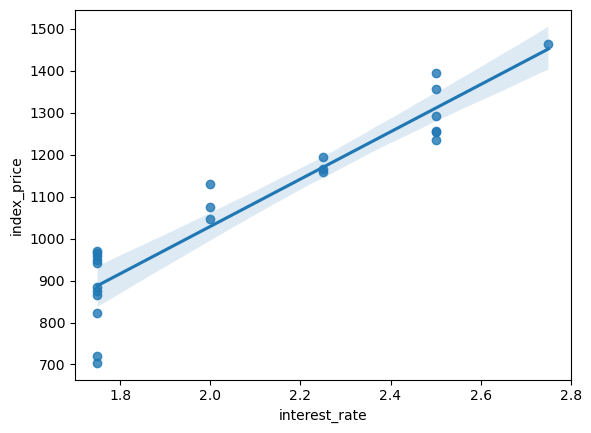

In [50]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

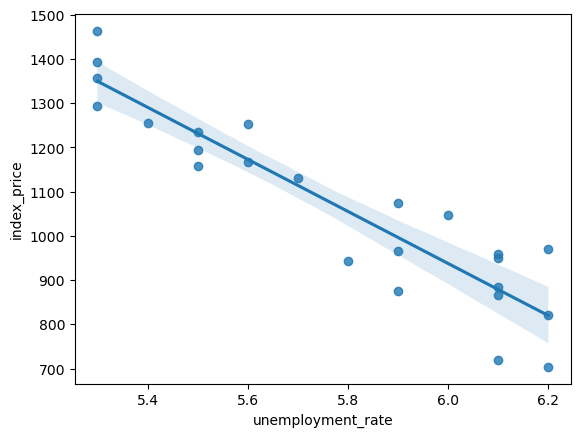

In [51]:
sns.regplot(x=df_index['unemployment_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

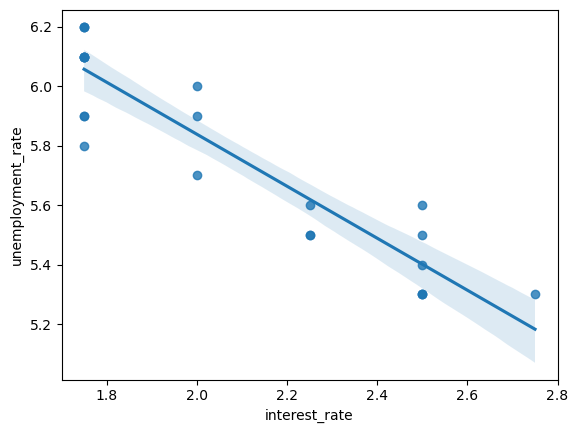

In [52]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test) ## remember not to use fit_transform for the X_test

In [54]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [55]:
regression.fit(X_train, y_train)

LinearRegression()

#### cross validation

In [56]:
## Let us try cross validation we will com back to this

from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error',cv=3)

In [57]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [58]:
## prediction
y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [59]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared error:', mse)
print('Mean Absolute error:', mae)
print('Root Mean Sqaured error:', rmse)


Mean Squared error: 5793.762887712579
Mean Absolute error: 59.935781523235526
Root Mean Sqaured error: 76.11677139574812


In [60]:
## using r squared
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print('r square:', score)


r square: 0.8278978091457142


In [61]:
## Using Adjusted r squared

adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted r square:', adjusted_score)

Adjusted r square: 0.713163015242857


### Assumptions


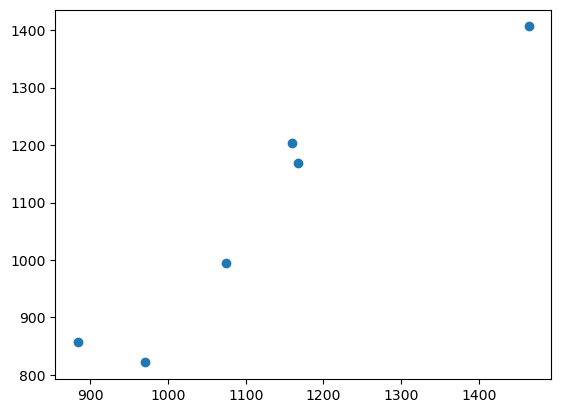

In [62]:
## 1. If there is linear relationship between the y_pred and y_test. The model performed well

plt.scatter(y_test, y_pred)

The relationship looks really good

In [63]:
## 2. We check the residuals. Then plot the kde plot. If it has a normal distribution then the model is good
residuals = y_test-y_pred
print(residuals)


8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


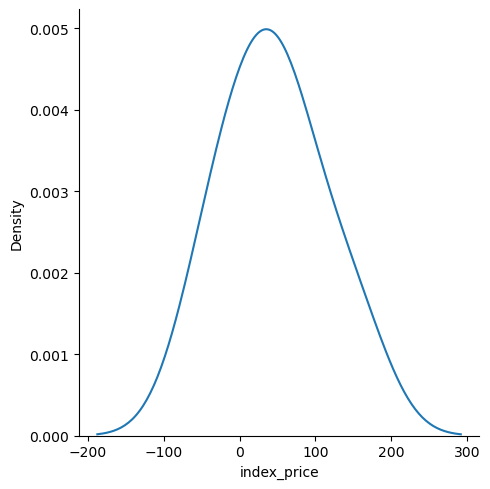

In [64]:
## plot the residuals
sns.displot(residuals,kind='kde')

The above looks really good. The residuals are normally distributed

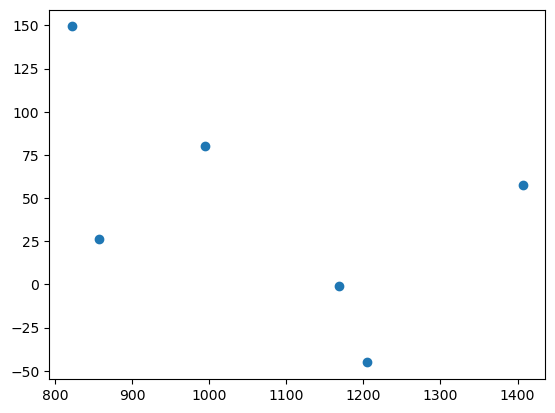

In [65]:
## 3. Create scatter plot with respect to prediction and residuals. If it is uniformly distributed (not showing any pattern) it is a good model


plt.scatter(y_pred, residuals)

The above is uniformly distributed. Therefore it is a good model

In [66]:
### OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train, X_train).fit()

In [67]:
model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 10 May 2026   Prob (F-statistic):                       0.754
Time:                        08:48:17   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [68]:
## Lets compare the coefficients between the OLS model and the Regression model

regression.coef_

array([  88.27275507, -116.25716066])

In [69]:
## We can see that the coefficients are the same

## Polynomial Regression

In [80]:
## Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [85]:
## We will create a dummy data that follows a polynomial relationship(quadratic in this case)
X1=6 * np.random.rand(100,1) - 3
y1= 0.5 * X1**2 + 1.5*X1 + 2 + np.random.randn(100,1)
## This y is the quadratic equation used
## The X_data is already scaled. No need for standard scaler


Text(0, 0.5, 'Y1 dataset')

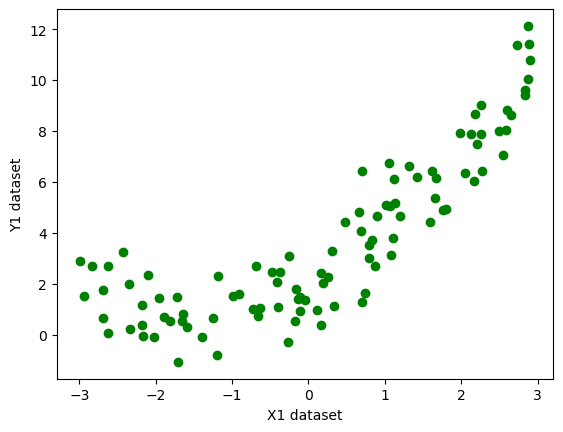

In [86]:
plt.scatter(X1,y1, color='g')
plt.xlabel('X1 dataset')
plt.ylabel('Y1 dataset')

From the plot we can see that the relationship is non linear

In [87]:
from sklearn.model_selection import train_test_split
X_train1,X_test1,y_train1,y_test1 = train_test_split(X1,y1,test_size=0.2, random_state=42)

In [91]:
## Lets implement simple linear regression
from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()
regression_1.fit(X_train1, y_train1)

LinearRegression()

In [92]:
from sklearn.metrics import r2_score
score1=r2_score(y_test1, regression_1.predict(X_test1))
score1

0.7280171938276367

Text(0, 0.5, 'Y')

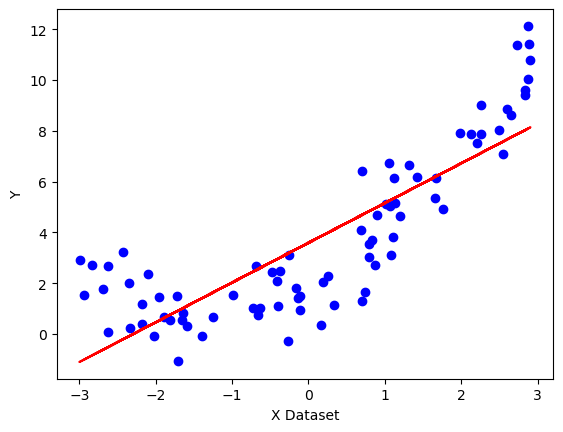

In [93]:
## Lets visualize the model
plt.plot(X_train1, regression_1.predict(X_train1), color='r')
plt.scatter(X_train1, y_train1, color='b')
plt.xlabel('X Dataset')
plt.ylabel('Y')

You can clearly see that the best fit line does not very accurately explain the data

Below we will increase the polynomial degree of the model to find the best fit that will generalize the data

In [94]:
## Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [127]:
poly=PolynomialFeatures(degree=2, include_bias=True) ## include all other terms that are below the degree 2

X_train_poly= poly.fit_transform(X_train1)
X_test_poly= poly.transform(X_test1) ## remember to use .transform() in test_data

In [99]:
X_train_poly

array([[ 1.        ,  1.06578792,  1.1359039 ],
       [ 1.        , -1.38923184,  1.9299651 ],
       [ 1.        , -2.42560547,  5.8835619 ],
       [ 1.        ,  1.11001432,  1.23213179],
       [ 1.        , -0.26084041,  0.06803772],
       [ 1.        ,  0.19433582,  0.03776641],
       [ 1.        , -1.71462155,  2.93992704],
       [ 1.        ,  2.25671421,  5.09275904],
       [ 1.        ,  2.87476089,  8.26425015],
       [ 1.        ,  0.8290008 ,  0.68724233],
       [ 1.        ,  1.98045127,  3.92218722],
       [ 1.        ,  2.20041422,  4.84182273],
       [ 1.        , -0.7296049 ,  0.53232331],
       [ 1.        ,  0.74505134,  0.5551015 ],
       [ 1.        ,  0.33431253,  0.11176487],
       [ 1.        ,  1.13774651,  1.29446713],
       [ 1.        , -1.95476434,  3.82110363],
       [ 1.        ,  2.83410783,  8.03216721],
       [ 1.        ,  1.1225081 ,  1.26002443],
       [ 1.        ,  1.0827816 ,  1.17241599],
       [ 1.        , -1.66053326,  2.757

In [100]:
X_test_poly

array([[ 1.00000000e+00,  1.62249384e+00,  2.63248626e+00],
       [ 1.00000000e+00,  2.16426311e+00,  4.68403482e+00],
       [ 1.00000000e+00,  2.27289329e+00,  5.16604389e+00],
       [ 1.00000000e+00, -9.12936025e-01,  8.33452186e-01],
       [ 1.00000000e+00, -1.72590267e-01,  2.97874003e-02],
       [ 1.00000000e+00,  1.11972502e-01,  1.25378413e-02],
       [ 1.00000000e+00,  2.59040273e+00,  6.71018631e+00],
       [ 1.00000000e+00,  6.60223726e-01,  4.35895368e-01],
       [ 1.00000000e+00,  2.18683222e+00,  4.78223517e+00],
       [ 1.00000000e+00,  1.79432403e+00,  3.21959871e+00],
       [ 1.00000000e+00,  4.83545289e-01,  2.33816047e-01],
       [ 1.00000000e+00,  3.08019417e-01,  9.48759613e-02],
       [ 1.00000000e+00,  1.59283834e+00,  2.53713399e+00],
       [ 1.00000000e+00,  1.68467546e-01,  2.83813140e-02],
       [ 1.00000000e+00,  2.04322989e+00,  4.17478840e+00],
       [ 1.00000000e+00, -1.19918152e+00,  1.43803633e+00],
       [ 1.00000000e+00, -2.16062242e+00

We have successfully converted the x features to a higher degree of 2.

Now we can train the model with this and view the performance.

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

regression_2 = LinearRegression()
regression_2.fit(X_train_poly, y_train1)

LinearRegression()

In [112]:
y_pred1 = regression_2.predict(X_test_poly)
score2= r2_score(y_test1, y_pred1)
score2

0.8044435062694442

Notice the accuracy improved. Now lets visualize the model

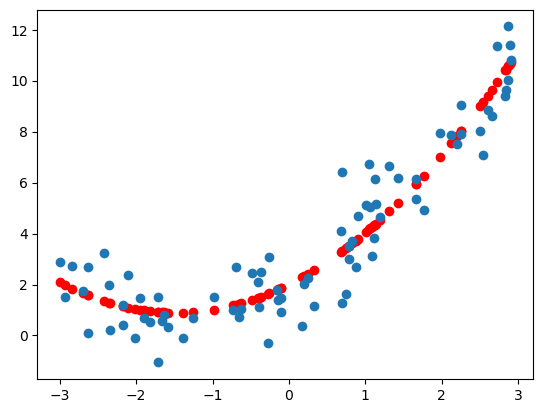

In [111]:
plt.scatter(X_train1, regression_2.predict(X_train_poly), color='red') ## We didnt use plot because it is not a straight line and can produce zig-zags
plt.scatter(X_train1, y_train1)

In [108]:
regression_2.coef_

array([[0.        , 1.51267472, 0.51286567]])

In [114]:
regression_2.intercept_

array([2.00727073])

In [121]:
## Now let us try to the highest degree of 3 to see if our model improves from 80%
poly1=PolynomialFeatures(degree=3, include_bias=True) ## include all other terms that are below the degree 2

X_train_poly3= poly1.fit_transform(X_train1)
X_test_poly3= poly1.transform(X_test1)


In [122]:
regression_3 = LinearRegression()
regression_3.fit(X_train_poly3, y_train1)

LinearRegression()

In [123]:
y_pred3 = regression_3.predict(X_test_poly3)
score3= r2_score(y_test1, y_pred3)
score3

0.7972190989221422

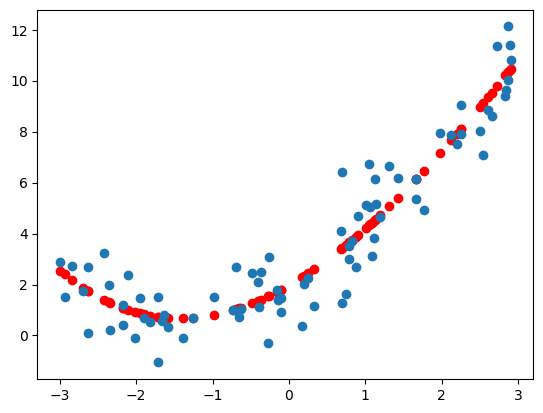

In [126]:
plt.scatter(X_train1, regression_3.predict(X_train_poly3), color='red') ## We didnt use plot because it is not a straight line and can produce zig-zags
plt.scatter(X_train1, y_train1)

Notice with a degree of 3, the accuracy dropped but not by much. from 80% to 79%. So we will continue with regression_2 model

In [128]:
## Now predicting new data
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new) ## we have to poly transform the new data so it can work with the polynomial model.
## NOTE: We used poly instead of poly3 which is the polynomial object we created for degree=2
X_new_poly


array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

You can see we transformed the new data to a higher degree of 2. If we used poly3 it would have 4 parameters because the degree is 3

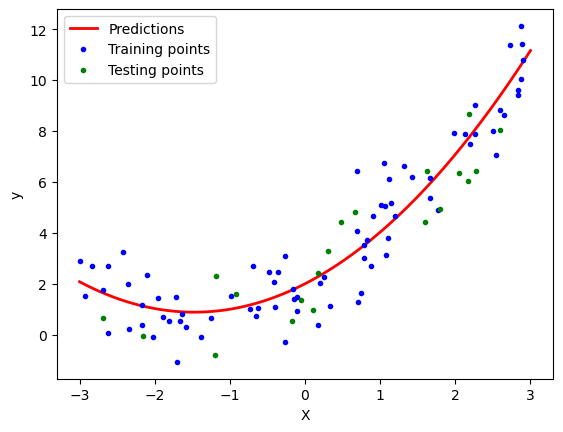

In [129]:
y_new = regression_2.predict(X_new_poly)
plt.plot(X_new, y_new, 'r-', linewidth=2, label='Predictions')
plt.plot(X_train1,y_train1,'b.', label='Training points')
plt.plot(X_test1, y_test1, 'g.', label='Testing points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### PIPELINE IN POLYNOMIAL

In [133]:
## We will use pipelining concept
from sklearn.pipeline import Pipeline

def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200, 1)

    poly_features=PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg=LinearRegression()
    ## In the pipeline arrange according to how you want the flow to be
    ## First we want the polynomial features created 
    ## Then the regression model
    ## The names can be anything, just ensure you pass in the correct object
    poly_regression=Pipeline([
        ('poly_features',poly_features), 
        ('lin_reg',lin_reg)
    ])
    poly_regression.fit(X_train1,y_train1) ##It creates the polynomial features and then fit the regression line
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new,y_pred_new,'r',label='Degree ' + str(degree), linewidth=3)
    plt.plot(X_train1, y_train1, 'b.', linewidth=3)
    plt.plot(X_test1, y_test1, 'g.', linewidth=3)
    plt.legend(loc='upper left')
    plt.axis([-4,4,0,10])

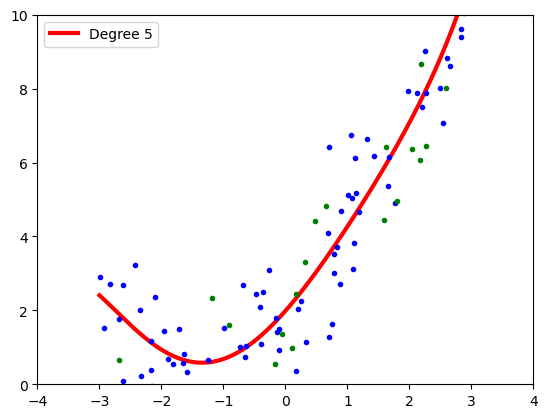

In [134]:
poly_regression(5)

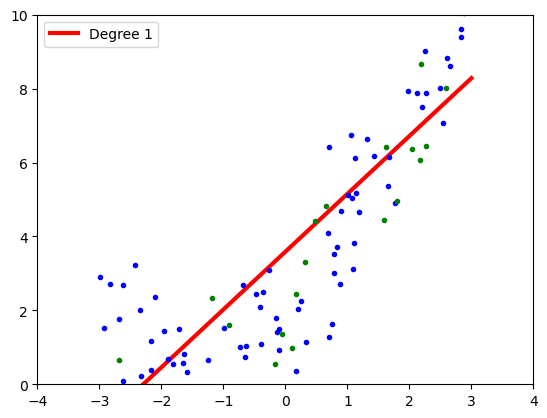

In [135]:
poly_regression(1)

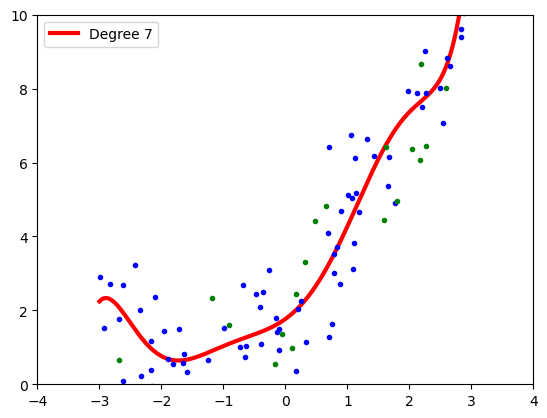

In [136]:
poly_regression(7)

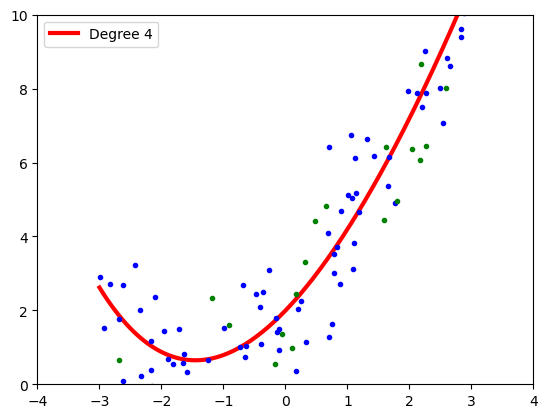

In [137]:
poly_regression(4)